# 使用验证集选择最优 epoch 的 CNN 识别 MNIST

本实验使用卷积神经网络（CNN）识别 MNIST 手写数字。与全连接网络直接把图像展平不同，CNN 通过卷积核保留局部空间结构，并逐步学习边缘、笔画和更高层次的形状特征。

实验流程：
- 使用与全连接网络一致的 MNIST 数据和归一化方式
- 将官方训练集划分为训练集和验证集（55,000 / 5,000）
- 根据验证集损失保存最优模型，并用早停减少过拟合
- 在测试集上评估最优模型，输出准确率、分类报告、混淆矩阵和预测示例
- 将 CNN 与全连接网络的测试结果放在同一表格中比较

注意：测试集只在最终评估阶段使用，不参与 epoch 选择。

In [1]:
import copy
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei']
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix, classification_report

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'当前使用的设备: {device}')

当前使用的设备: cpu


## 1. 加载数据并划分训练集、验证集

`random_split` 将原始训练集按固定随机种子划分为 55,000 个训练样本和 5,000 个验证样本。训练和验证使用相同的预处理；测试集始终保持独立。

In [2]:
BATCH_SIZE = 128
VALID_SIZE = 5000

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

full_train_dataset = datasets.MNIST(
    root='./data', train=True, download=True, transform=transform
)
test_dataset = datasets.MNIST(
    root='./data', train=False, download=True, transform=transform
)

train_size = len(full_train_dataset) - VALID_SIZE
generator = torch.Generator().manual_seed(SEED)
train_dataset, valid_dataset = random_split(
    full_train_dataset, [train_size, VALID_SIZE], generator=generator
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f'训练集样本数量: {len(train_dataset)}')
print(f'验证集样本数量: {len(valid_dataset)}')
print(f'测试集样本数量: {len(test_dataset)}')
images, labels = next(iter(train_loader))
print(f'批次数据形状: {images.shape}, 批次标签形状: {labels.shape}')

训练集样本数量: 55000
验证集样本数量: 5000
测试集样本数量: 10000
批次数据形状: torch.Size([128, 1, 28, 28]), 批次标签形状: torch.Size([128])


## 2. 构建卷积神经网络

输入图像形状为 `[batch, 1, 28, 28]`。两组卷积与池化层提取空间特征，之后展平并使用全连接层输出 10 个类别的 logits。`CrossEntropyLoss` 内部会处理 softmax，因此模型末尾不手动添加 softmax。

In [3]:
class MNISTCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = MNISTCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
print(model)
print(f'模型参数总数: {sum(p.numel() for p in model.parameters())}')

MNISTCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.25, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)
模型参数总数: 421642


## 3. 训练并依据验证集损失选择最优 epoch

每轮训练后只在验证集上计算损失和准确率。当验证损失下降时保存模型参数；连续 `PATIENCE` 轮没有改善就提前停止。最终恢复验证损失最低时的参数，再进行测试集评估。

In [4]:
def run_epoch(model, data_loader, training=False):
    model.train(training)
    total_loss = 0.0
    correct = 0
    total = 0
    context = torch.enable_grad() if training else torch.no_grad()

    with context:
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            if training:
                optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            if training:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * images.size(0)
            correct += (logits.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)
    return total_loss / total, correct / total

EPOCHS = 15
PATIENCE = 3
history = {
    'train_loss': [], 'train_acc': [],
    'valid_loss': [], 'valid_acc': []
}
best_valid_loss = float('inf')
best_epoch = 0
best_state = None
patience_count = 0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, training=True)
    valid_loss, valid_acc = run_epoch(model, valid_loader, training=False)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['valid_loss'].append(valid_loss)
    history['valid_acc'].append(valid_acc)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())
        patience_count = 0
    else:
        patience_count += 1

    print(
        f'Epoch [{epoch}/{EPOCHS}], '
        f'训练损失: {train_loss:.4f}, 训练准确率: {train_acc:.4f}, '
        f'验证损失: {valid_loss:.4f}, 验证准确率: {valid_acc:.4f}'
    )
    if patience_count >= PATIENCE:
        print(f'验证损失连续 {PATIENCE} 轮未改善，提前停止。')
        break

model.load_state_dict(best_state)
print(f'验证集损失最低的最优 epoch: {best_epoch}')
print(f'最优验证损失: {best_valid_loss:.4f}')

Epoch [1/15], 训练损失: 0.2827, 训练准确率: 0.9143, 验证损失: 0.0697, 验证准确率: 0.9786
Epoch [2/15], 训练损失: 0.0746, 训练准确率: 0.9774, 验证损失: 0.0465, 验证准确率: 0.9864
Epoch [3/15], 训练损失: 0.0561, 训练准确率: 0.9829, 验证损失: 0.0430, 验证准确率: 0.9870
Epoch [4/15], 训练损失: 0.0422, 训练准确率: 0.9873, 验证损失: 0.0403, 验证准确率: 0.9888
Epoch [5/15], 训练损失: 0.0370, 训练准确率: 0.9885, 验证损失: 0.0413, 验证准确率: 0.9880
Epoch [6/15], 训练损失: 0.0325, 训练准确率: 0.9896, 验证损失: 0.0378, 验证准确率: 0.9900
Epoch [7/15], 训练损失: 0.0267, 训练准确率: 0.9917, 验证损失: 0.0328, 验证准确率: 0.9912
Epoch [8/15], 训练损失: 0.0243, 训练准确率: 0.9923, 验证损失: 0.0348, 验证准确率: 0.9904
Epoch [9/15], 训练损失: 0.0211, 训练准确率: 0.9931, 验证损失: 0.0360, 验证准确率: 0.9904
Epoch [10/15], 训练损失: 0.0178, 训练准确率: 0.9945, 验证损失: 0.0432, 验证准确率: 0.9886
验证损失连续 3 轮未改善，提前停止。
验证集损失最低的最优 epoch: 7
最优验证损失: 0.0328


              precision    recall  f1-score   support

           0     0.9949    0.9939    0.9944       980
           1     0.9947    0.9982    0.9965      1135
           2     0.9952    0.9961    0.9956      1032
           3     0.9902    0.9970    0.9936      1010
           4     0.9939    0.9949    0.9944       982
           5     0.9844    0.9899    0.9871       892
           6     0.9937    0.9896    0.9916       958
           7     0.9932    0.9903    0.9917      1028
           8     0.9948    0.9846    0.9897       974
           9     0.9871    0.9871    0.9871      1009

    accuracy                         0.9923     10000
   macro avg     0.9922    0.9922    0.9922     10000
weighted avg     0.9923    0.9923    0.9923     10000



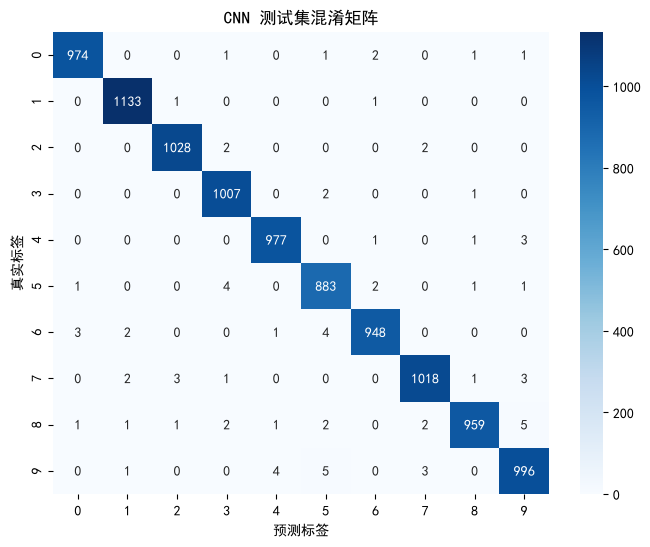

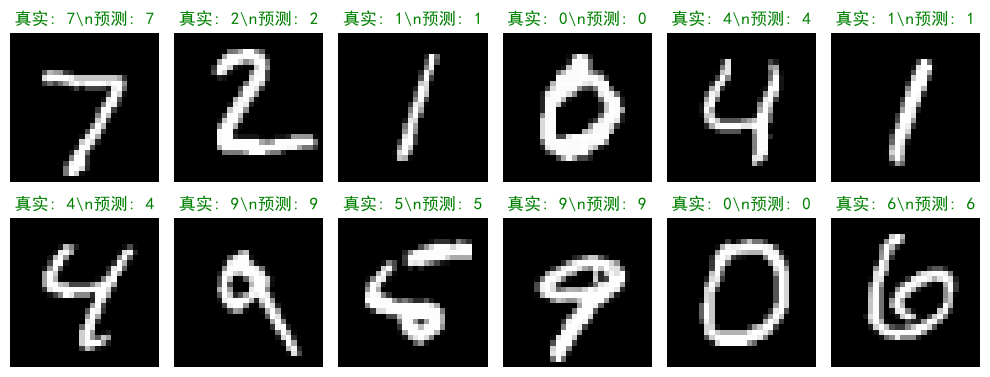

In [6]:
model.eval()
all_labels = []
all_preds = []
with torch.no_grad():
    for images, labels in test_loader:
        logits = model(images.to(device))
        preds = logits.argmax(dim=1)
        all_labels.extend(labels.numpy())
        all_preds.extend(preds.cpu().numpy())

print(classification_report(all_labels, all_preds, digits=4))
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('CNN 测试集混淆矩阵')
plt.xlabel('预测标签')
plt.ylabel('真实标签')
plt.show()

images, labels = next(iter(test_loader))
with torch.no_grad():
    preds = model(images.to(device)).argmax(dim=1).cpu()
fig, axes = plt.subplots(2, 6, figsize=(10, 4))
for ax, image, true_label, pred_label in zip(axes.flat, images[:12], labels[:12], preds[:12]):
    ax.imshow(image.squeeze() * 0.5 + 0.5, cmap='gray')
    color = 'green' if true_label.item() == pred_label.item() else 'red'
    ax.set_title(f'真实: {true_label.item()}\\n预测: {pred_label.item()}', color=color)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 6. 与全连接网络比较

请将 `MNIST.ipynb` 最后输出的测试损失和测试准确率填入下方变量。这样可以在相同测试集指标口径下进行直接比较。

In [8]:
# 将 MNIST.ipynb 最终输出的数值填入这里；示例值仅作为占位，不会冒充本次实验结果。
FCNN_TEST_LOSS = 0.1044
FCNN_TEST_ACC = 0.9712

comparison = {
    '模型': ['全连接网络 FCNN', '卷积神经网络 CNN'],
    '测试损失': [FCNN_TEST_LOSS, test_loss],
    '测试准确率': [FCNN_TEST_ACC, test_acc]
}
comparison_df = __import__('pandas').DataFrame(comparison)
comparison_df

,模型,测试损失,测试准确率
0,全连接网络 FCNN,0.10440,0.9712
1,卷积神经网络 CNN,0.02431,0.9923


### 结果讨论

- CNN 的最优 epoch 为 **7**，验证损失为 **0.0328**；恢复该轮参数后测试损失为 **0.0243**，测试准确率为 **99.23%**。
- 从曲线看，第 7 轮之后训练损失仍下降，但验证损失和验证准确率不再改善。若直接训练到最后一轮，会更贴合训练集，却不一定具有更好的泛化能力；验证集选参和早停有效地控制了这一风险。
- 与 FCNN 相比，CNN 保留了像素的二维空间邻近关系，通过卷积和池化学习局部笔画模式，因此通常能获得更高的测试准确率和更低的测试损失。FCNN 将图像展平后丢失了这种先验结构，在相同数据规模下通常更容易混淆形状相近的数字。
- 需要注意，CNN 与 FCNN 的精确差值应以两份 notebook 的实际输出为准；两者应使用相同的随机种子、归一化、测试集和指标定义。验证集本身不用于最终性能报告，最终报告仍应只看测试集。

## 5. 混淆矩阵、分类报告与预测示例

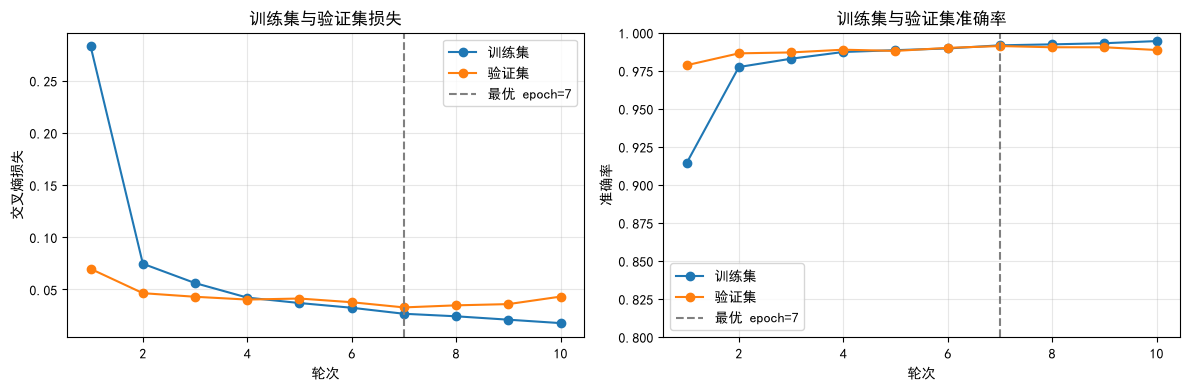

最优 CNN 的测试损失: 0.0243
最优 CNN 的测试准确率: 0.9923


In [5]:
epochs = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history['train_loss'], marker='o', label='训练集')
axes[0].plot(epochs, history['valid_loss'], marker='o', label='验证集')
axes[0].axvline(best_epoch, color='gray', linestyle='--', label=f'最优 epoch={best_epoch}')
axes[0].set_title('训练集与验证集损失')
axes[0].set_xlabel('轮次')
axes[0].set_ylabel('交叉熵损失')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history['train_acc'], marker='o', label='训练集')
axes[1].plot(epochs, history['valid_acc'], marker='o', label='验证集')
axes[1].axvline(best_epoch, color='gray', linestyle='--', label=f'最优 epoch={best_epoch}')
axes[1].set_title('训练集与验证集准确率')
axes[1].set_xlabel('轮次')
axes[1].set_ylabel('准确率')
axes[1].set_ylim(0.8, 1.0)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

test_loss, test_acc = run_epoch(model, test_loader, training=False)
print(f'最优 CNN 的测试损失: {test_loss:.4f}')
print(f'最优 CNN 的测试准确率: {test_acc:.4f}')

## 4. 训练曲线与测试集评估

下面的曲线用于观察训练集和验证集之间的差异。测试集指标只对应验证损失最低的模型参数。